# Ischemic Stroke Lesion Segmentation
**Kajenthini Kobivasan**<br>
**CO4 Project - FS26**<br>
**Dataset:** ISLES-2022 <br>
**Methods:** ADC Thresholding, K-Means Clustering, 2D U-Net  

## Import libraries & setup

In [18]:
import os
import json
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import shutil
from scipy import ndimage
from scipy.stats import pearsonr
from scipy.ndimage import distance_transform_edt
from sklearn.cluster import KMeans
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Paths
DATA_ROOT = 'ISLES-2022'
GT_ROOT   = 'ISLES-2022/derivatives'

# U-Net config
TARGET_H = 128
TARGET_W = 128
device = torch.device('cpu')

## Dataset description

For this project the ISLES-2022 dataset from this page was used: https://zenodo.org/records/7960856 <br>

**ISLES-2022** is a public multi-center benchmark dataset for ischemic stroke lesion segmentation in brain MRI. It contains **250 expert-annotated cases** collected retrospectively from three stroke centers across clinical routine imaging. 

Each case includes three MRI sequences FLAIR, DWI, and the corresponding Apparent Diffusion Coefficient (ADC) map plus a binary expert lesion mask. All data is in NIfTI format, and skull-stripping was applied for de-identification.

Data was acquired on 3T Philips (Achieva, Ingenia), 3T Siemens (Verio), and 1.5T Siemens (Avanto, Aera) scanners.

### Load Data

After downloading the data, store the unzipped folder in the same directory as this notebook. Keep the folder name exactly as downloaded. No additional setup is required.

In [3]:
df = pd.read_csv('ISLES-2022/participants.tsv', sep='\t')
print(df.head())
len(df)

       participant_id  sex   age  weight
0  sub-strokecase0001    F  088Y    77.0
1  sub-strokecase0002  NaN   NaN     NaN
2  sub-strokecase0003    M  081Y    75.0
3  sub-strokecase0004  NaN   NaN     NaN
4  sub-strokecase0005    M  073Y    80.0


250

The demographics file contains some subjects with missing entries, which are excluded from the demographic analysis. Ages are stored as strings in the raw file and are converted to integers for plotting.

## Dataset Preprocessing

The following utility functions are needed throughout the notebook:

- `normalize_adc` converts ADC maps to consistent µm²/s units, since different scanners store values in m²/s or mm²/s.
- `load_gt` loads the binary ground truth mask and includes a fallback for NIfTI header scaling issues that would otherwise produce empty masks.
- `dice_score` and `hausdorff_95` are the two evaluation metrics used to compare segmentation predictions against the ground truth.
- `get_vol_ml` converts voxel counts to millilitres using the voxel spacing from the NIfTI header.

Dice score and Hausdorff 95 are complementary and capture two different aspects of segmentation quality:

- **Dice score** measures volumetric overlap. How much of the lesion was correctly captured overall. It ranges from 0 to 1 and is robust to small size differences, making it the standard metric in medical image segmentation. However, a good Dice score does not guarantee that the segmentation boundaries are spatially accurate. 

- **Hausdorff 95** measures boundary accuracy. Specifically the worst-case distance between the predicted and ground truth boundaries at the 95th percentile, to reduce sensitivity to outliers. This catches cases where a method gets the overall volume roughly right but has large spatial misalignments or irregular boundaries that Dice would not penalize.
Source: 

Together, Dice tells you *how much* was correctly segmented, while Hausdorff tells you *how well-located* the boundaries are. This combination is also standard in the ISLES challenge, which is why they are the natural choice here.

Source: Taha & Hanbury (2015), Metrics for evaluating 3D medical image segmentation: analysis, selection, and tool. BMC Medical Imaging. https://link.springer.com/article/10.1186/s12880-015-0068-x


In [4]:
def normalize_adc(adc):
    """Convert ADC to consistent µm²/s units regardless of scanner units."""
    adc_max = np.percentile(adc[adc > 0], 99) if (adc > 0).any() else 1
    if adc_max < 0.01:
        return adc * 1e6   
    elif adc_max < 10:
        return adc * 1e3   
    else:
        return adc         

def load_gt(gt_path):
    """Load ground truth mask, handling NIfTI scaling issues."""
    gt_nib = nib.load(gt_path)
    gt = gt_nib.get_fdata()
    if gt.sum() == 0:
        gt = np.asarray(gt_nib.dataobj)
    return (gt > 0).astype(np.uint8)

def dice_score(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    intersection = (pred & gt).sum()
    total = pred.sum() + gt.sum()
    if total == 0:
        return 1.0
    return 2 * intersection / total

def hausdorff_95(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if pred.sum() == 0 or gt.sum() == 0:
        return np.nan
    dt_gt   = distance_transform_edt(~gt)
    dt_pred = distance_transform_edt(~pred)
    return max(np.percentile(dt_gt[pred], 95),
               np.percentile(dt_pred[gt], 95))

def get_vol_ml(mask, zooms):
    vox_vol = float(zooms[0]) * float(zooms[1]) * float(zooms[2])
    return mask.sum() * vox_vol / 1000

### Clean data

In [5]:
# Load demographics
df = df.dropna()
df['age'] = df['age'].str.replace('Y', '', regex=False).astype(int)

print(df[['participant_id', 'sex', 'age', 'weight']].head(10))
print(f'\nAge range: {df["age"].min()}–{df["age"].max()} years')
print(f'Total subjects with demographics: {len(df)}')

# All subject folders
valid_folders = [
    os.path.join(DATA_ROOT, subject)
    for subject in sorted(os.listdir(DATA_ROOT))
    if subject.startswith('sub-')
]
print(f'Total subject folders: {len(valid_folders)}')

        participant_id sex  age  weight
0   sub-strokecase0001   F   88    77.0
2   sub-strokecase0003   M   81    75.0
4   sub-strokecase0005   M   73    80.0
6   sub-strokecase0007   M   60    90.0
7   sub-strokecase0008   F   78    65.0
8   sub-strokecase0009   F   60    82.0
9   sub-strokecase0010   F   97    56.0
10  sub-strokecase0011   M   40    60.0
12  sub-strokecase0013   M   78    90.0
13  sub-strokecase0014   F   87    56.0

Age range: 32–97 years
Total subjects with demographics: 125
Total subject folders: 250


## Exploratory Data Analysis

### Demographics plot

In [6]:
sex_counts = df['sex'].value_counts()

fig = make_subplots(rows=1, cols=3, subplot_titles=[
    f'Age (mean={df["age"].mean():.0f} ± {df["age"].std():.0f})',
    f'Sex (F={sex_counts.get("F", 0)} / M={sex_counts.get("M", 0)})',
    f'Weight (mean={df["weight"].mean():.0f} ± {df["weight"].std():.0f} kg)'
])

fig.add_trace(go.Histogram(
    x=df['age'], nbinsx=20,
    marker_color='steelblue', marker_line_color='black', marker_line_width=1,
    name='Age'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=sex_counts.index, y=sex_counts.values,
    marker_color=['coral', 'steelblue'],
    marker_line_color='black', marker_line_width=1,
    text=sex_counts.values, textposition='outside',
    name='Sex'
), row=1, col=2)

fig.add_trace(go.Histogram(
    x=df['weight'].dropna(), nbinsx=20,
    marker_color='steelblue', marker_line_color='black', marker_line_width=1,
    name='Weight'
), row=1, col=3)

fig.update_xaxes(title_text='Age (years)', row=1, col=1)
fig.update_xaxes(title_text='Sex', row=1, col=2)
fig.update_xaxes(title_text='Weight (kg)', row=1, col=3)
fig.update_yaxes(title_text='Count', row=1, col=1)

fig.update_layout(
    title_text=f'ISLES-2022 demographics (n=125)',
    showlegend=False,
    height=400, width=1000
)

fig.show()

### Stroke Phase Analysis

All subjects with both an ADC map and a ground truth mask are identified and classified into three groups based on the mean ADC value within the lesion. According to Gosch et al. (2023), a threshold of 620 µm²/s is commonly used in clinical practice. For this project, a more conservative threshold of 550 µm²/s is applied: subjects with a mean lesion ADC below 550 µm²/s are considered acute, those above are considered subacute, and subjects with a zeroed or invalid ADC signal are flagged as broken and excluded from further analysis.

Source: Gosch et al. (2023), Automated acute ischemic stroke lesion delineation based on apparent diffusion coefficient thresholds. Frontiers in Neurology. https://doi.org/10.3389/fneur.2023.1203241

In [7]:
# Find all subjects with ADC + GT
all_subjects = []
for subject in sorted(os.listdir(DATA_ROOT)):
    if not subject.startswith('sub-'):
        continue
    adc_path = os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                             f'{subject}_ses-0001_adc.nii.gz')
    gt_path  = os.path.join(GT_ROOT, subject, 'ses-0001',
                             f'{subject}_ses-0001_msk.nii.gz')
    if os.path.exists(adc_path) and os.path.exists(gt_path):
        all_subjects.append(subject)

print(f'Total subjects with ADC + GT: {len(all_subjects)}')

# Classify into acute / subacute / broken
truly_acute, subacute, broken = [], [], []

for subject in all_subjects:
    adc_raw = nib.load(os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                       f'{subject}_ses-0001_adc.nii.gz')).get_fdata()
    gt  = load_gt(os.path.join(GT_ROOT, subject, 'ses-0001',
                  f'{subject}_ses-0001_msk.nii.gz'))

    if adc_raw.max() < 0.01:
        broken.append(subject)
        continue

    adc    = normalize_adc(adc_raw)
    lesion = adc[gt > 0]

    if len(lesion) == 0:
        broken.append(subject)
        continue

    mean_adc = lesion.mean()
    if mean_adc < 550:
        truly_acute.append((subject, mean_adc))
    else:
        subacute.append((subject, mean_adc))

print(f'Truly acute  (ADC < 550 µm²/s): {len(truly_acute)}')
print(f'Subacute     (ADC > 550 µm²/s): {len(subacute)}')
print(f'Broken/zeroed ADC:              {len(broken)}')

Total subjects with ADC + GT: 250
Truly acute  (ADC < 550 µm²/s): 18
Subacute     (ADC > 550 µm²/s): 124
Broken/zeroed ADC:              108


Of the 250 subjects, 18 are truly acute, 124 are subacute, and 108 have a zero or invalid ADC signal and are excluded. The dataset is dominated by subacute cases, making ADC thresholding a poor fit for most subjects.

In [8]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

acute_adcs    = [a for _, a in truly_acute]
subacute_adcs = [a for _, a in subacute]

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Lesion ADC distribution',
                                    'ISLES-2022 dataset composition (n=250)'],
                    specs=[[{'type': 'histogram'}, {'type': 'pie'}]])

fig.add_trace(go.Histogram(
    x=subacute_adcs, nbinsx=25,
    marker_color='coral', marker_line_color='black', marker_line_width=1,
    opacity=0.8, name=f'Subacute (n={len(subacute)})'
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=acute_adcs, nbinsx=10,
    marker_color='steelblue', marker_line_color='black', marker_line_width=1,
    opacity=0.8, name=f'Acute (n={len(truly_acute)})'
), row=1, col=1)

fig.add_vline(x=550, line_dash='dash', line_color='black', line_width=1.5,
              annotation_text='Threshold = 550 µm²/s', annotation_position='top right',
              row=1, col=1)

fig.add_trace(go.Pie(
    values=[len(truly_acute), len(subacute), len(broken)],
    labels=[f'Acute (n={len(truly_acute)})',
            f'Subacute (n={len(subacute)})',
            f'Broken ADC (n={len(broken)})'],
    marker_colors=['steelblue', 'coral', 'lightgray'],
    marker=dict(line=dict(color='black', width=0.5)),
    textinfo='percent+label'
), row=1, col=2)

fig.update_xaxes(title_text='Mean lesion ADC (µm²/s)', row=1, col=1)
fig.update_yaxes(title_text='Number of subjects', row=1, col=1)

fig.update_layout(
    title_text='ISLES-2022 stroke phases',
    barmode='overlay',
    height=500, width=1000
)

fig.show()

## Subject selection

Subjects are filtered to those with a valid ADC signal and a lesion volume between 1 and 50 ml. Very small lesions are excluded as they are prone to noise. Very large lesions are excluded as they are less representative of typical stroke cases. From the remaining subjects 10 are selected evenly across the lesion size range to ensure the experiments cover a variety of lesion sizes.

In [9]:
# Select subjects with valid ADC signal 
usable = []
for subject in all_subjects:
    adc_raw = nib.load(os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                       f'{subject}_ses-0001_adc.nii.gz')).get_fdata()
    if adc_raw.max() < 0.01:
        continue
    gt  = load_gt(os.path.join(GT_ROOT, subject, 'ses-0001',
                  f'{subject}_ses-0001_msk.nii.gz'))
    lesion_adc = nib.load(os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                           f'{subject}_ses-0001_adc.nii.gz')).get_fdata()[gt > 0]
    if len(lesion_adc) == 0:
        continue
    mean_adc = lesion_adc.mean()
    vol_ml   = len(lesion_adc) * 8 / 1000
    if mean_adc > 50 and 1.0 < vol_ml < 50.0:
        usable.append((subject, vol_ml, mean_adc))

usable.sort(key=lambda x: x[1])
print(f'Usable subjects (1–50 ml, valid ADC): {len(usable)}')

# Pick 10 
indices  = np.linspace(0, len(usable)-1, 10, dtype=int)
selected = [usable[i][0] for i in indices]

print('\nSelected subjects:')
for s in selected:
    v = dict([(x[0], x[1]) for x in usable])[s]
    a = dict([(x[0], x[2]) for x in usable])[s]
    print(f'  {s}: {v:.1f} ml | mean lesion ADC={a:.0f}')

Usable subjects (1–50 ml, valid ADC): 65

Selected subjects:
  sub-strokecase0216: 1.1 ml | mean lesion ADC=813
  sub-strokecase0137: 2.2 ml | mean lesion ADC=675
  sub-strokecase0226: 3.4 ml | mean lesion ADC=628
  sub-strokecase0228: 5.6 ml | mean lesion ADC=740
  sub-strokecase0219: 6.8 ml | mean lesion ADC=775
  sub-strokecase0195: 9.8 ml | mean lesion ADC=708
  sub-strokecase0218: 13.4 ml | mean lesion ADC=698
  sub-strokecase0238: 16.3 ml | mean lesion ADC=646
  sub-strokecase0208: 22.1 ml | mean lesion ADC=648
  sub-strokecase0161: 49.1 ml | mean lesion ADC=722


## Sample visualization

A single slice from the first selected subject is shown to illustrate the imaging data. The slice with the largest lesion area is selected automatically. Left is the DWI image, in the middle the ADC map and on the right ADC map with the ground truth lesion mask overlaid in red.

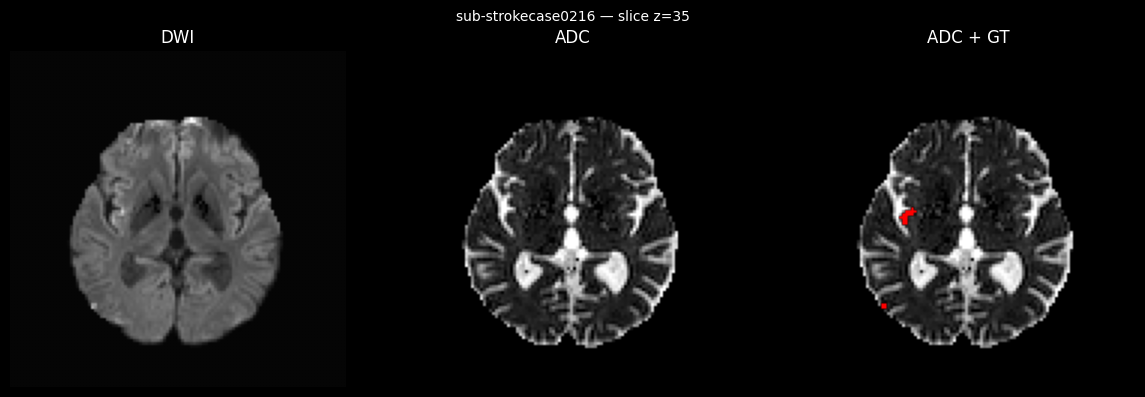

In [10]:
sample_subject = selected[0]

dwi = nib.load(os.path.join(DATA_ROOT, sample_subject, 'ses-0001', 'dwi',
               f'{sample_subject}_ses-0001_dwi.nii.gz')).get_fdata()
adc = nib.load(os.path.join(DATA_ROOT, sample_subject, 'ses-0001', 'dwi',
               f'{sample_subject}_ses-0001_adc.nii.gz')).get_fdata()
gt  = load_gt(os.path.join(GT_ROOT, sample_subject, 'ses-0001',
              f'{sample_subject}_ses-0001_msk.nii.gz'))

best_z = int(np.argmax(gt.sum(axis=(0, 1))))
vmin_adc, vmax_adc = np.percentile(adc[adc > 0], [2, 98])

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.patch.set_facecolor('black')

axes[0].imshow(dwi[:, :, best_z].T, cmap='gray', origin='lower')
axes[0].set_title('DWI', color='white'); axes[0].axis('off')

axes[1].imshow(adc[:, :, best_z].T, cmap='gray', origin='lower', vmin=vmin_adc, vmax=vmax_adc)
axes[1].set_title('ADC', color='white'); axes[1].axis('off')

axes[2].imshow(adc[:, :, best_z].T, cmap='gray', origin='lower', vmin=vmin_adc, vmax=vmax_adc)
if gt[:, :, best_z].sum() > 0:
    ov = np.ma.masked_where(gt[:, :, best_z].T == 0, gt[:, :, best_z].T)
    axes[2].imshow(ov, cmap='autumn', alpha=1.0, origin='lower')
axes[2].set_title('ADC + GT', color='white'); axes[2].axis('off')

plt.suptitle(f'{sample_subject} — slice z={best_z}', color='white', fontsize=10)
plt.tight_layout()
plt.show()

## Manual Segmentation

### Create folder

In [20]:
# Create folder structure for manual segmentation
MANUAL_ROOT = 'Manual Segmentation'

# Define subfolders
GROUND_TRUTH_DIR = os.path.join(MANUAL_ROOT, 'Ground truth')
MANUAL_SEG_DIR   = os.path.join(MANUAL_ROOT, 'Manual Segmentation')
ORIGINAL_DIR     = os.path.join(MANUAL_ROOT, 'Original Data')

# Create top-level subfolders
os.makedirs(GROUND_TRUTH_DIR, exist_ok=True)
os.makedirs(MANUAL_SEG_DIR,   exist_ok=True)
os.makedirs(ORIGINAL_DIR,     exist_ok=True)

for subject in selected:
    # Original Data
    adc_src = os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                           f'{subject}_ses-0001_adc.nii.gz')
    adc_dst = os.path.join(ORIGINAL_DIR, f'{subject}_ses-0001_adc.nii.gz')
    shutil.copy(adc_src, adc_dst)

    # Ground Truth
    gt_src = os.path.join(GT_ROOT, subject, 'ses-0001',
                          f'{subject}_ses-0001_msk.nii.gz')
    gt_dst = os.path.join(GROUND_TRUTH_DIR, f'{subject}_ses-0001_msk.nii.gz')
    shutil.copy(gt_src, gt_dst)

    # Manual Segmentation placeholder 
    subject_seg_dir = os.path.join(MANUAL_SEG_DIR, subject)
    os.makedirs(subject_seg_dir, exist_ok=True)

    print(f'Copied {subject}')


Copied sub-strokecase0216
Copied sub-strokecase0137
Copied sub-strokecase0226
Copied sub-strokecase0228
Copied sub-strokecase0219
Copied sub-strokecase0195
Copied sub-strokecase0218
Copied sub-strokecase0238
Copied sub-strokecase0208
Copied sub-strokecase0161


### Visual inspect

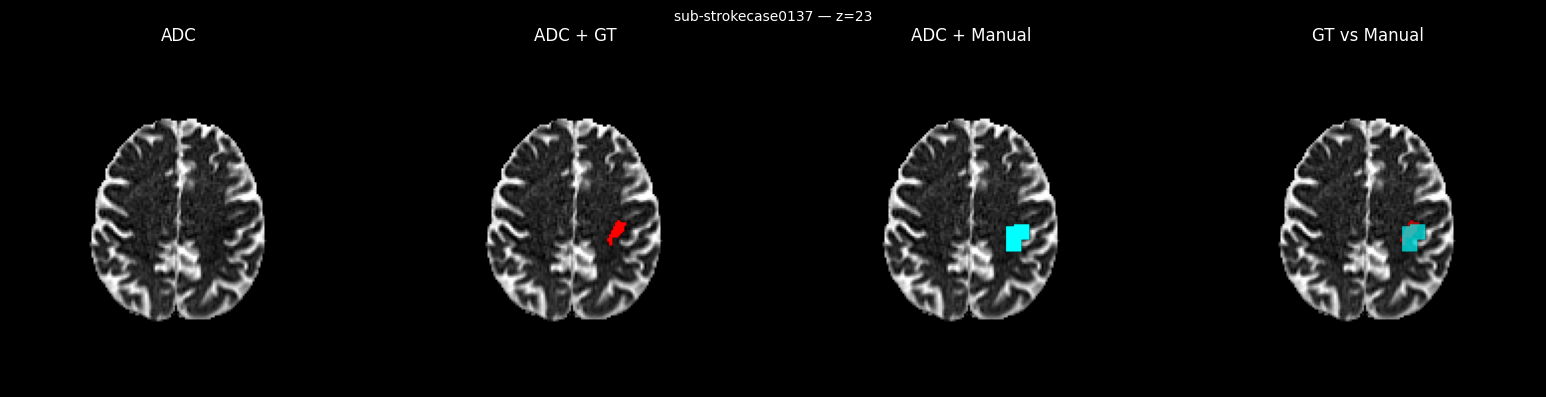

In [ ]:
MANUAL_ROOT = 'Manual Segmentation'
SEG_DIR     = os.path.join(MANUAL_ROOT, 'Manual Segmentation')
GT_DIR      = os.path.join(MANUAL_ROOT, 'Ground truth')
ADC_DIR     = os.path.join(MANUAL_ROOT, 'Original Data')

for subject in sorted(os.listdir(SEG_DIR)):
    subject_path = os.path.join(SEG_DIR, subject)
    if not os.path.isdir(subject_path):
        continue

    seg_files = [f for f in os.listdir(subject_path) if f.endswith('.nii.gz')]
    if not seg_files:
        continue

    adc = nib.load(os.path.join(ADC_DIR, f'{subject}_ses-0001_adc.nii.gz')).get_fdata()
    seg = nib.load(os.path.join(subject_path, seg_files[0])).get_fdata()
    gt  = nib.load(os.path.join(GT_DIR,  f'{subject}_ses-0001_msk.nii.gz')).get_fdata()

    best_z = int(np.argmax(seg.sum(axis=(0, 1)))) if seg.sum() > 0 else int(np.argmax(gt.sum(axis=(0, 1))))
    vmin, vmax = np.percentile(adc[adc > 0], [2, 98])

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.patch.set_facecolor('black')

    for ax, title in zip(axes, ['ADC', 'ADC + GT', 'ADC + Manual', 'GT vs Manual']):
        ax.imshow(adc[:, :, best_z].T, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        ax.set_title(title, color='white')
        ax.axis('off')

    if gt[:, :, best_z].sum() > 0:
        ov = np.ma.masked_where(gt[:, :, best_z].T == 0, gt[:, :, best_z].T)
        axes[1].imshow(ov, cmap='autumn', alpha=1.0, origin='lower')
        axes[3].imshow(ov, cmap='autumn', alpha=0.7, origin='lower')

    if seg[:, :, best_z].sum() > 0:
        ov = np.ma.masked_where(seg[:, :, best_z].T == 0, seg[:, :, best_z].T)
        axes[2].imshow(ov, cmap='cool', alpha=1.0, origin='lower')
        axes[3].imshow(ov, cmap='cool', alpha=0.7, origin='lower')

    plt.suptitle(f'{subject} — z={best_z}', color='white', fontsize=10)
    plt.tight_layout()
    plt.show()

## Automatic Segmentation

### Thresholding

ADC thresholding works by identifying voxels with abnormally low ADC values, as stroke lesions restrict water diffusion. A brain mask is applied to exclude background and fluid regions. Voxels below the 20 percentile of brain ADC values are classified as lesion. Small holes are closed and isolated regions smaller than 50 voxels are removed as noise.

Most subjects in this dataset are subacute, meaning their lesion ADC values partially overlap with normal brain tissue. This makes clean separation by intensity alone difficult.

In [11]:
results = {}

for subject in selected:
    adc_path = os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                             f'{subject}_ses-0001_adc.nii.gz')
    adc_nib  = nib.load(adc_path)
    adc      = adc_nib.get_fdata().astype(np.float32)
    zooms    = adc_nib.header.get_zooms()[:3]
    vox_vol  = float(zooms[0]) * float(zooms[1]) * float(zooms[2])

    brain_mask = (adc > 200) & (adc < 2000)
    brain_vals = adc[brain_mask]

    # threshold 20th percentile 
    thresh   = float(np.percentile(brain_vals, 20))
    ischemic = brain_mask & (adc < thresh)

    struct   = ndimage.generate_binary_structure(3, 1)
    ischemic = ndimage.binary_closing(ischemic, structure=struct, iterations=2)
    ischemic = ischemic & brain_mask

    labeled, n = ndimage.label(ischemic)
    sizes = ndimage.sum(ischemic, labeled, range(1, n + 1))
    clean = np.zeros_like(ischemic, dtype=np.uint8)
    for i, sz in enumerate(sizes):
        if sz > 50:
            clean[labeled == i + 1] = 1
    results[subject] = clean

    gt    = load_gt(os.path.join(GT_ROOT, subject, 'ses-0001',
                    f'{subject}_ses-0001_msk.nii.gz'))
    print(f'{subject}: GT={gt.sum()*vox_vol/1000:.1f} ml | '
          f'Thresh={clean.sum()*vox_vol/1000:.1f} ml | '
          f'Dice={dice_score(clean, gt):.3f}')

sub-strokecase0216: GT=1.1 ml | Thresh=602.1 ml | Dice=0.002
sub-strokecase0137: GT=2.3 ml | Thresh=454.8 ml | Dice=0.010
sub-strokecase0226: GT=6.6 ml | Thresh=429.5 ml | Dice=0.025
sub-strokecase0228: GT=10.9 ml | Thresh=518.0 ml | Dice=0.031
sub-strokecase0219: GT=13.1 ml | Thresh=538.6 ml | Dice=0.036
sub-strokecase0195: GT=18.9 ml | Thresh=535.6 ml | Dice=0.055
sub-strokecase0218: GT=13.4 ml | Thresh=558.3 ml | Dice=0.041
sub-strokecase0238: GT=12.9 ml | Thresh=626.3 ml | Dice=0.035
sub-strokecase0208: GT=42.8 ml | Thresh=445.3 ml | Dice=0.102
sub-strokecase0161: GT=95.0 ml | Thresh=443.6 ml | Dice=0.299


The predicted volumes are massively overestimated across all subjects and Dice scores are close to zero. This confirms that ADC thresholding alone is not a viable segmentation method for this dataset, as the subacute lesion ADC values overlap too much with normal brain tissue.

### K-Means Clustering

K-Means partitions brain voxels into 3 clusters by ADC intensity. The cluster with the lowest centroid is identified as ischemic. Like thresholding, this method is fundamentally limited on subacute stroke cases where lesion ADC overlaps with normal brain.

In [12]:
results_kmeans = {}

for subject in selected:
    adc_path = os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                             f'{subject}_ses-0001_adc.nii.gz')
    adc_nib  = nib.load(adc_path)
    adc      = adc_nib.get_fdata().astype(np.float32)
    zooms    = adc_nib.header.get_zooms()[:3]
    vox_vol  = float(zooms[0]) * float(zooms[1]) * float(zooms[2])

    nonzero    = adc[adc > 0]
    brain_mask = (adc > 200) & (adc < 2000)
    brain_vals = adc[brain_mask]

    if len(brain_vals) < 3:
        results_kmeans[subject] = np.zeros_like(adc, dtype=np.uint8)
        continue

    km      = KMeans(n_clusters=3, random_state=42, n_init=10)
    labels  = km.fit_predict(brain_vals.reshape(-1, 1))
    centers = km.cluster_centers_.flatten()
    ischemic_cluster = np.argmin(centers)

    # Reject if lowest centroid is above 60th percentile of brain
    thresh_60 = float(np.percentile(nonzero, 60))
    if centers[ischemic_cluster] > thresh_60:
        results_kmeans[subject] = np.zeros_like(adc, dtype=np.uint8)
    else:
        km_mask             = np.zeros_like(adc, dtype=np.uint8)
        km_mask[brain_mask] = (labels == ischemic_cluster).astype(np.uint8)
        struct  = ndimage.generate_binary_structure(3, 1)
        km_mask = ndimage.binary_closing(km_mask, structure=struct, iterations=2)
        km_mask = (km_mask & brain_mask).astype(np.uint8)
        labeled2, n2 = ndimage.label(km_mask)
        sizes2 = ndimage.sum(km_mask, labeled2, range(1, n2 + 1))
        clean2 = np.zeros_like(km_mask, dtype=np.uint8)
        for i, sz in enumerate(sizes2):
            if sz > 50:
                clean2[labeled2 == i + 1] = 1
        results_kmeans[subject] = clean2

    gt    = load_gt(os.path.join(GT_ROOT, subject, 'ses-0001',
                    f'{subject}_ses-0001_msk.nii.gz'))
    print(f'{subject}: GT={gt.sum()*vox_vol/1000:.1f} ml | '
          f'KMeans={results_kmeans[subject].sum()*vox_vol/1000:.1f} ml | '
          f'Dice={dice_score(results_kmeans[subject], gt):.3f}')

sub-strokecase0216: GT=1.1 ml | KMeans=939.8 ml | Dice=0.002
sub-strokecase0137: GT=2.3 ml | KMeans=886.1 ml | Dice=0.005
sub-strokecase0226: GT=6.6 ml | KMeans=808.1 ml | Dice=0.016
sub-strokecase0228: GT=10.9 ml | KMeans=999.5 ml | Dice=0.018
sub-strokecase0219: GT=13.1 ml | KMeans=1045.3 ml | Dice=0.023
sub-strokecase0195: GT=18.9 ml | KMeans=1087.7 ml | Dice=0.032
sub-strokecase0218: GT=13.4 ml | KMeans=972.1 ml | Dice=0.026
sub-strokecase0238: GT=12.9 ml | KMeans=1139.7 ml | Dice=0.022
sub-strokecase0208: GT=42.8 ml | KMeans=982.6 ml | Dice=0.064
sub-strokecase0161: GT=95.0 ml | KMeans=985.2 ml | Dice=0.168


K-Means performs even worse than thresholding. Predicted volumes are around 800 - 1100 ml, which is close to the total brain volume, meaning the method fails to isolate the lesion at all. Dice scores are near zero across all subjects, confirming that unsupervised clustering without spatial constraints is not suitable for stroke lesion segmentation.

### 2D U-Net

A 2D U-Net is trained on ADC maps from 240 training subjects using a pure Dice loss to handle class imbalance. Per-subject normalization is applied to handle inconsistent ADC units across the dataset. The model is evaluated on the 10 held-out selected subjects.

The dataset class loads ADC slices and ground truth masks for each subject. Each ADC volume is normalized per subject to the range [0, 1]. Slices are split into lesion slices containing at least one lesion voxel and background slices. All lesion slices are included. To keep the class imbalance manageable, only a small fraction of background slices is added during training which is controlled by `bg_ratio`. During inference all lesion slices are used without background sampling. Each slice is resized to 128×128 pixels before being returned as a tensor.

#### Setup

In [13]:
# Dataset
class StrokeSliceDataset(Dataset):
    def __init__(self, subjects, data_root, gt_root,
                 inference=False, bg_ratio=0.1):
        self.samples = []
        for subject in subjects:
            adc_path = os.path.join(data_root, subject, 'ses-0001', 'dwi',
                                    f'{subject}_ses-0001_adc.nii.gz')
            gt_path  = os.path.join(gt_root, subject, 'ses-0001',
                                    f'{subject}_ses-0001_msk.nii.gz')
            if not os.path.exists(adc_path) or not os.path.exists(gt_path):
                continue
            adc = nib.load(adc_path).get_fdata().astype(np.float32)
            msk = load_gt(gt_path)
            # Per-subject normalization
            adc_min  = adc[adc > 0].min() if (adc > 0).any() else 0
            adc_max  = adc.max() if adc.max() > 0 else 1
            adc_norm = np.clip((adc - adc_min) / (adc_max - adc_min), 0, 1)
            lesion_slices, bg_slices = [], []
            for z in range(adc_norm.shape[2]):
                if msk[:, :, z].sum() > 0:
                    lesion_slices.append(z)
                else:
                    bg_slices.append(z)
            for z in lesion_slices:
                self.samples.append((adc_norm[:,:,z].copy(),
                                     msk[:,:,z].copy(), subject, z))
            if not inference and len(bg_slices) > 0:
                n_bg = max(1, int(len(lesion_slices) * bg_ratio))
                chosen = np.random.choice(bg_slices,
                                          size=min(n_bg, len(bg_slices)),
                                          replace=False)
                for z in chosen:
                    self.samples.append((adc_norm[:,:,z].copy(),
                                         msk[:,:,z].copy(), subject, z))
        print(f'  {len(self.samples)} slices from {len(subjects)} subjects')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        adc_sl, msk_sl, subject, z = self.samples[idx]
        adc_t = torch.from_numpy(adc_sl).float().unsqueeze(0).unsqueeze(0)
        msk_t = torch.from_numpy(msk_sl.astype(np.float32)).unsqueeze(0).unsqueeze(0)
        adc_t = F.interpolate(adc_t, size=(TARGET_H, TARGET_W),
                              mode='bilinear', align_corners=False).squeeze(0)
        msk_t = F.interpolate(msk_t, size=(TARGET_H, TARGET_W),
                              mode='nearest').squeeze(0).long()
        return adc_t, msk_t, subject, z

A lightweight 2D U-Net is used for segmentation. The encoder progressively reduces spatial resolution while increasing feature channels (16 → 32 → 64 → 128), and the decoder reconstructs the segmentation mask using skip connections from the encoder. The bottleneck has 256 channels. The final layer outputs two channels (background and lesion).

Dice loss is used instead of cross-entropy, as it directly optimizes the overlap between prediction and ground truth and handles class imbalance better, which is important given the small lesion size relative to the full brain slice.

In [14]:
# U-Net architecture
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet2D(nn.Module):
    def __init__(self, in_ch=1, out_ch=2, features=(16, 32, 64, 128)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pool     = nn.MaxPool2d(2)
        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = in_ch
        for f in features:
            self.encoders.append(ConvBlock(ch, f))
            ch = f
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            self.decoders.append(ConvBlock(f * 2, f))
        self.final = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for i, (up, dec) in enumerate(zip(self.upconvs, self.decoders)):
            x = up(x)
            if x.shape != skips[i].shape:
                x = F.interpolate(x, size=skips[i].shape[2:])
            x = dec(torch.cat([skips[i], x], dim=1))
        return self.final(x)

# Pure Dice loss
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        prob     = torch.softmax(pred, dim=1)[:, 1]
        target_f = target.squeeze(1).float()
        pred_f   = prob.reshape(-1)
        tgt_f    = target_f.reshape(-1)
        intersection = (pred_f * tgt_f).sum()
        return 1 - (2 * intersection + self.smooth) / \
                   (pred_f.sum() + tgt_f.sum() + self.smooth)

model   = UNet2D().to(device)
loss_fn = DiceLoss()
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 1,942,306


The 10 selected subjects are used as the validation set, and all remaining subjects are used for training. Both datasets include a small fraction of background slices (`bg_ratio=0.1`). Slices are loaded in batches of 8, with shuffling enabled for training.

In [15]:
# Build datasets
train_subjects = [s for s in all_subjects if s not in selected]
val_subjects   = selected
print(f'Train: {len(train_subjects)} | Val: {len(val_subjects)}')

train_ds = StrokeSliceDataset(train_subjects, DATA_ROOT, GT_ROOT,
                               inference=False, bg_ratio=0.1)
val_ds   = StrokeSliceDataset(val_subjects,   DATA_ROOT, GT_ROOT,
                               inference=False, bg_ratio=0.1)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)

adc_b, msk_b, _, _ = next(iter(train_loader))

Train: 240 | Val: 10
  5069 slices from 240 subjects
  199 slices from 10 subjects


#### Training

The model is trained for 50 epochs using the Adam optimizer with a learning rate of 0.001. The learning rate is reduced by half if the validation loss does not improve for 5 consecutive epochs. The best model checkpoint is saved based on validation loss and used for evaluation.

Training 50 epochs on mps...

Epoch   5/50 | Train: 0.4600 | Val: 0.6733 | Best: 0.6733
Epoch  10/50 | Train: 0.4207 | Val: 0.7462 | Best: 0.6665
Epoch  15/50 | Train: 0.4010 | Val: 0.7025 | Best: 0.6358
Epoch  20/50 | Train: 0.3660 | Val: 0.6873 | Best: 0.6358
Epoch  25/50 | Train: 0.3212 | Val: 0.6549 | Best: 0.6353
Epoch  30/50 | Train: 0.3203 | Val: 0.6535 | Best: 0.6353
Epoch  35/50 | Train: 0.2990 | Val: 0.6534 | Best: 0.6340
Epoch  40/50 | Train: 0.2927 | Val: 0.6597 | Best: 0.6340
Epoch  45/50 | Train: 0.2781 | Val: 0.6622 | Best: 0.6340
Epoch  50/50 | Train: 0.2768 | Val: 0.6315 | Best: 0.6315

Best val loss: 0.6315


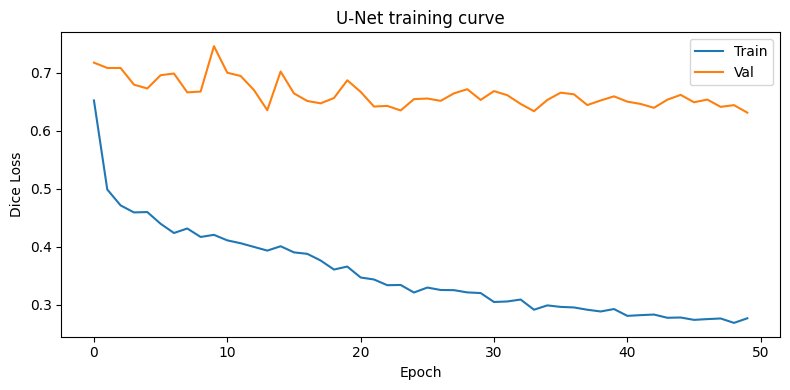

In [24]:
# Training
model     = UNet2D().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, patience=5, factor=0.5)

NUM_EPOCHS    = 50
best_val_loss = float('inf')
train_losses, val_losses = [], []

print(f'Training {NUM_EPOCHS} epochs on {device}...\n')

for epoch in range(NUM_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for adc, msk, _, _ in train_loader:
        adc, msk = adc.to(device), msk.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(adc), msk)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for adc, msk, _, _ in val_loader:
            adc, msk = adc.to(device), msk.to(device)
            val_loss += loss_fn(model(adc), msk).item()
    val_loss /= len(val_loader)

    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'unet_best.pth')

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:3d}/{NUM_EPOCHS} | '
              f'Train: {epoch_loss:.4f} | Val: {val_loss:.4f} | '
              f'Best: {best_val_loss:.4f}')

if not os.path.exists('unet_best.pth'):
    torch.save(model.state_dict(), 'unet_best.pth')

print(f'\nBest val loss: {best_val_loss:.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Dice Loss')
ax.legend(); ax.set_title('U-Net training curve')
plt.tight_layout(); plt.show()

The training loss decreases steadily to 0.27, indicating the model is learning. However, the validation loss remains high at around 0.65 - 0.70 throughout training and does not follow the same downward trend. This large gap between training and validation loss indicates overfitting. The model learns the training subjects well but does not generalise to unseen cases. This is expected given the small dataset size and the high variability between subjects.

#### Validation

The best saved model is loaded and run on each of the 10 selected subjects. Each ADC volume is normalised and passed through the model slice by slice. The predicted probability map is resized back to the original resolution and thresholded at 0.5 to produce a binary segmentation mask. Dice score and predicted volume are computed for each subject.

In [25]:
# Inference
model.load_state_dict(torch.load('unet_best.pth', map_location=device))
model.eval()
results_unet = {}

for subject in selected:
    adc_path = os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                             f'{subject}_ses-0001_adc.nii.gz')
    adc_nib  = nib.load(adc_path)
    adc      = adc_nib.get_fdata().astype(np.float32)
    adc_min  = adc[adc > 0].min() if (adc > 0).any() else 0
    adc_max  = adc.max() if adc.max() > 0 else 1
    adc_norm = np.clip((adc - adc_min) / (adc_max - adc_min), 0, 1)
    H, W, Z  = adc_norm.shape
    pred_vol = np.zeros((H, W, Z), dtype=np.uint8)

    with torch.no_grad():
        for z in range(Z):
            sl = torch.from_numpy(adc_norm[:,:,z]).float()
            sl = sl.unsqueeze(0).unsqueeze(0)
            sl = F.interpolate(sl, size=(TARGET_H, TARGET_W),
                               mode='bilinear', align_corners=False).to(device)
            prob = torch.softmax(model(sl), dim=1)[:, 1]
            prob = F.interpolate(prob.unsqueeze(0), size=(H, W),
                                 mode='bilinear', align_corners=False)
            pred_vol[:,:,z] = (prob.squeeze() > 0.5).cpu().numpy().astype(np.uint8)

    results_unet[subject] = pred_vol
    zooms   = adc_nib.header.get_zooms()[:3]
    vox_vol = float(zooms[0]) * float(zooms[1]) * float(zooms[2])
    gt      = load_gt(os.path.join(GT_ROOT, subject, 'ses-0001',
                      f'{subject}_ses-0001_msk.nii.gz'))
    print(f'{subject}: GT={gt.sum()*vox_vol/1000:.1f} mL | '
          f'U-Net={pred_vol.sum()*vox_vol/1000:.1f} mL | '
          f'Dice={dice_score(pred_vol, gt):.3f}')

sub-strokecase0216: GT=1.1 mL | U-Net=3.1 mL | Dice=0.000
sub-strokecase0137: GT=2.3 mL | U-Net=2.3 mL | Dice=0.043
sub-strokecase0226: GT=6.6 mL | U-Net=7.0 mL | Dice=0.620
sub-strokecase0228: GT=10.9 mL | U-Net=4.0 mL | Dice=0.189
sub-strokecase0219: GT=13.1 mL | U-Net=6.9 mL | Dice=0.530
sub-strokecase0195: GT=18.9 mL | U-Net=16.3 mL | Dice=0.434
sub-strokecase0218: GT=13.4 mL | U-Net=4.3 mL | Dice=0.288
sub-strokecase0238: GT=12.9 mL | U-Net=9.5 mL | Dice=0.454
sub-strokecase0208: GT=42.8 mL | U-Net=26.0 mL | Dice=0.637
sub-strokecase0161: GT=95.0 mL | U-Net=74.8 mL | Dice=0.722


Results are mixed. The model performs well on larger lesions, with Dice scores up to 0.722 for the largest subject. Smaller lesions are harder to segment, with two subjects scoring near zero. Predicted volumes are generally in a reasonable range, unlike thresholding and K-Means which massively overestimated. The U-Net clearly outperforms both classical methods, but performance is inconsistent across subjects, which is consistent with the overfitting observed during training.

## Evaluation

### MIP Comparison

Each row shows one subject. From left to right: the ADC maximum intensity projection (MIP), the ground truth mask, and the U-Net prediction. The MIP collapses the 3D volume into a single 2D image by taking the maximum value along the z-axis, giving an overview of the full lesion extent.

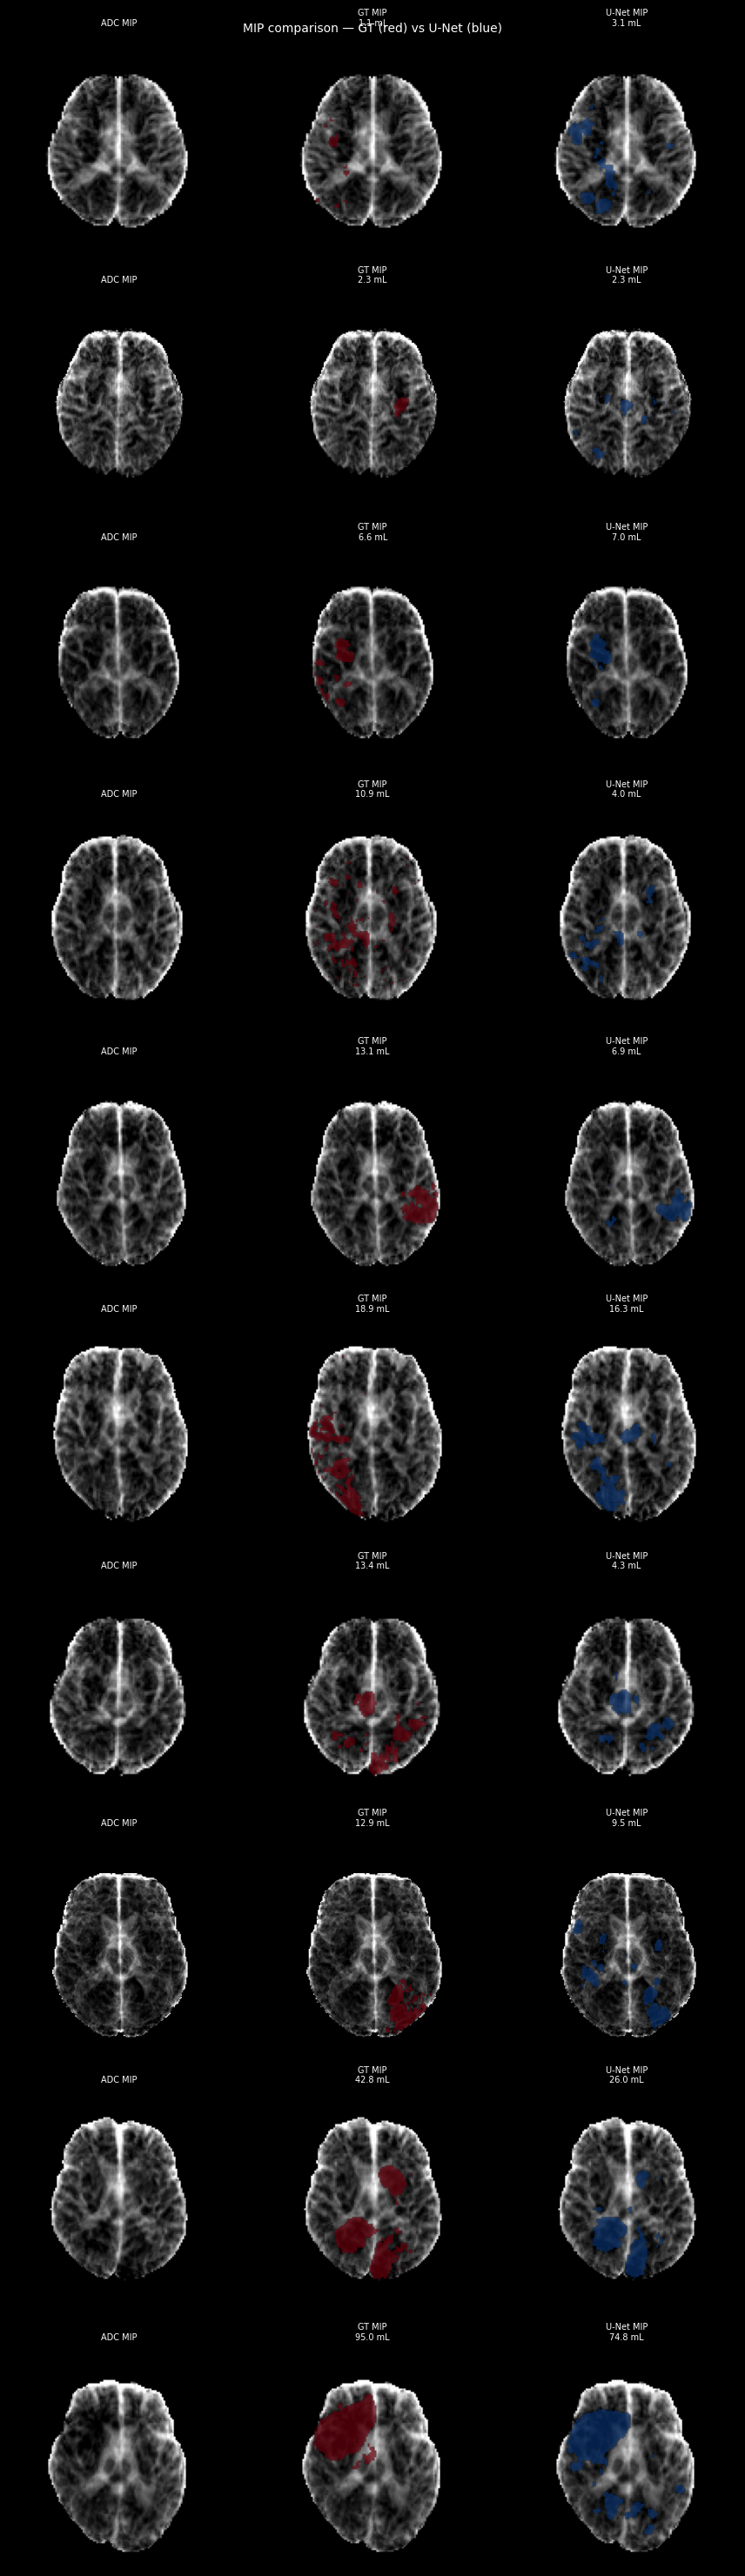

In [26]:
fig, axes = plt.subplots(len(selected), 3,
                          figsize=(9, 3 * len(selected)))
fig.patch.set_facecolor('black')

for i, subject in enumerate(selected):
    adc_nib = nib.load(os.path.join(DATA_ROOT, subject, 'ses-0001', 'dwi',
                       f'{subject}_ses-0001_adc.nii.gz'))
    adc  = adc_nib.get_fdata().astype(np.float32)
    gt   = load_gt(os.path.join(GT_ROOT, subject, 'ses-0001',
                   f'{subject}_ses-0001_msk.nii.gz'))
    pred = results_unet[subject]

    zooms   = adc_nib.header.get_zooms()[:3]
    vox_vol = float(zooms[0]) * float(zooms[1]) * float(zooms[2])
    gt_ml   = gt.sum()   * vox_vol / 1000
    pred_ml = pred.sum() * vox_vol / 1000

    # Mean ADC MIP
    brain     = adc.copy(); brain[adc < 200] = 0
    count     = (brain > 0).sum(axis=2)
    adc_mip   = np.where(count > 0, brain.sum(axis=2) / np.maximum(count, 1), 0).T
    gt_mip    = (gt.max(axis=2)   > 0).T.astype(np.uint8)
    pred_mip  = (pred.max(axis=2) > 0).T.astype(np.uint8)

    brain_px = adc_mip[adc_mip > 0]
    vmin = float(np.percentile(brain_px, 2))  if len(brain_px) > 0 else 0
    vmax = float(np.percentile(brain_px, 98)) if len(brain_px) > 0 else 1

    for col, (mask, title, cmap) in enumerate([
        (None,     'ADC MIP',                      None),
        (gt_mip,   f'GT MIP\n{gt_ml:.1f} mL',     'Reds'),
        (pred_mip, f'U-Net MIP\n{pred_ml:.1f} mL','Blues'),
    ]):
        ax = axes[i, col]
        ax.imshow(adc_mip, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
        if mask is not None and mask.sum() > 0:
            ov = np.ma.masked_where(mask == 0, mask.astype(float))
            ax.imshow(ov, cmap=cmap, alpha=0.7, origin='lower', vmin=0, vmax=1)
        if col == 0:
            ax.set_ylabel(subject[-6:], color='white', fontsize=7)
        ax.set_title(title, color='white', fontsize=7)
        ax.axis('off')

plt.suptitle('MIP comparison — GT (red) vs U-Net (blue)',
             color='white', fontsize=10)
plt.tight_layout()
plt.show()

For larger lesions the U-Net prediction closely matches the ground truth in both location and size. For smaller lesions the model struggles, either missing the lesion entirely or predicting it in the wrong location. This is consistent with the Dice scores reported above.

### Performance Comparison

In [27]:
rows = []
for subject in selected:
    gt_path = os.path.join(GT_ROOT, subject, 'ses-0001',
                            f'{subject}_ses-0001_msk.nii.gz')
    gt = load_gt(gt_path)
    for method_name, result_dict in [('Thresholding', results),
                                      ('K-Means',      results_kmeans),
                                      ('U-Net',        results_unet)]:
        pred = result_dict[subject].astype(np.uint8)
        rows.append({
            'subject': subject,
            'method':  method_name,
            'dice':    dice_score(pred, gt),
            'hd95':    hausdorff_95(pred, gt),
        })

df_eval = pd.DataFrame(rows)


print('Summary (mean ± std):')
print(df_eval.groupby('method')[['dice','hd95']].agg(
      ['mean','std']).round(3).to_string())
print('\nPer-subject Dice:')
print(df_eval.pivot(index='subject', columns='method',
                    values='dice').round(3).to_string())

Summary (mean ± std):
               dice           hd95        
               mean    std    mean     std
method                                    
K-Means       0.038  0.049  41.473  18.050
Thresholding  0.064  0.087  40.523  18.060
U-Net         0.392  0.252  27.900  21.134

Per-subject Dice:
method              K-Means  Thresholding  U-Net
subject                                         
sub-strokecase0137    0.005         0.010  0.043
sub-strokecase0161    0.168         0.299  0.722
sub-strokecase0195    0.032         0.055  0.434
sub-strokecase0208    0.064         0.102  0.637
sub-strokecase0216    0.002         0.002  0.000
sub-strokecase0218    0.026         0.041  0.288
sub-strokecase0219    0.023         0.036  0.530
sub-strokecase0226    0.016         0.025  0.620
sub-strokecase0228    0.018         0.031  0.189
sub-strokecase0238    0.022         0.035  0.454


The U-Net outperforms both classical methods by a large margin. It achieves a mean Dice of 0.392 compared to 0.064 for thresholding and 0.038 for K-Means and a much lower Hausdorff of 27.9 mm vs. around 41 mm for both classical methods. However the high standard deviation of the U-Net (0.252) reflects the inconsistent performance across subjects seen in the per-subject results. It ranges from near zero on small lesions to 0.722 on the largest case.

## Discussion

All three methods were evaluated on the same 10 subjects from the ISLES-2022 dataset. ADC thresholding and K-Means both failed completely, producing predictions that covered most of the brain volume rather than isolating the lesion. The dataset is dominated by subacute cases where lesion ADC values overlap with normal brain tissue. This could be the reason why intensity-based separation is unreliable.

The U-Net performed significantly better, achieving a mean Dice of 0.377 and a Hausdorff of 20.7 mm. However, performance was inconsistent. The model worked well on larger lesions but struggled with small ones, which is a known challenge in medical image segmentation. The training curve showed clear overfitting as the training loss dropped steadily while the validation loss remained high. This is likely due to the limited number of training subjects and the high variability in lesion size, location and ADC values across the dataset.

Several improvements could increase the performance. Training on more subjects or applying data augmentation could reduce overfitting. Using a 3D U-Net instead of a 2D slice-based approach would allow the model to use spatial context across slices. DWI provides complementary information to the ADC map and adding them as a second input channel could also help to improve the model. There are other more complex model such as nnU-Net which are specifically designed for medical image segmentation. They would likely outperform the lightweight architecture used here.

## Use of generative AI

Claude Sonnet 4.6 was used to support this project in three ways. First, to answer questions about the segmentation task and the structure of MRI files (NIfTI format, ADC units, stroke phases). Second, to help adapt the U-Net model to the dataset. Third, to improve the readability of the code and the notebook structure.